# Week 3 — Mixture Models, EM, Clustering and PCA
**Course:** 21CSC305P Machine Learning · **Unit 3 – Mixture models and EM**

**Topics covered:** K-means clustering · mixtures of Gaussians · EM (an alternative view) · factor analysis · PCA ·
choosing the number of latent dimensions · clustering: measuring dissimilarity, evaluating clustering output, hierarchical clustering.

**Practice tasks**
1. Implement K-means clustering, mixtures of Gaussians and hierarchical clustering to categorise data
2. Create a program to perform PCA

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

from sklearn.datasets import load_iris, load_digits, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score
from sklearn.model_selection import cross_val_score

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
PAL = sns.color_palette("tab10")

## Part A — Theory in code

### A1. Measuring dissimilarity
Clustering needs a notion of distance. Choice of metric changes what "similar" means.

| metric | formula | note |
|---|---|---|
| Euclidean | $\sqrt{\sum(x_i-y_i)^2}$ | sensitive to scale → standardise first |
| Manhattan | $\sum\lvert x_i-y_i\rvert$ | robust to single large differences |
| Cosine | $1-\frac{x\cdot y}{\lVert x\rVert\lVert y\rVert}$ | direction only (text, embeddings) |
| Mahalanobis | $\sqrt{(x-y)^\top\Sigma^{-1}(x-y)}$ | accounts for correlation / scale |

euclidean      2.7037
manhattan      4.5000
cosine         0.0883
mahalanobis    3.5077


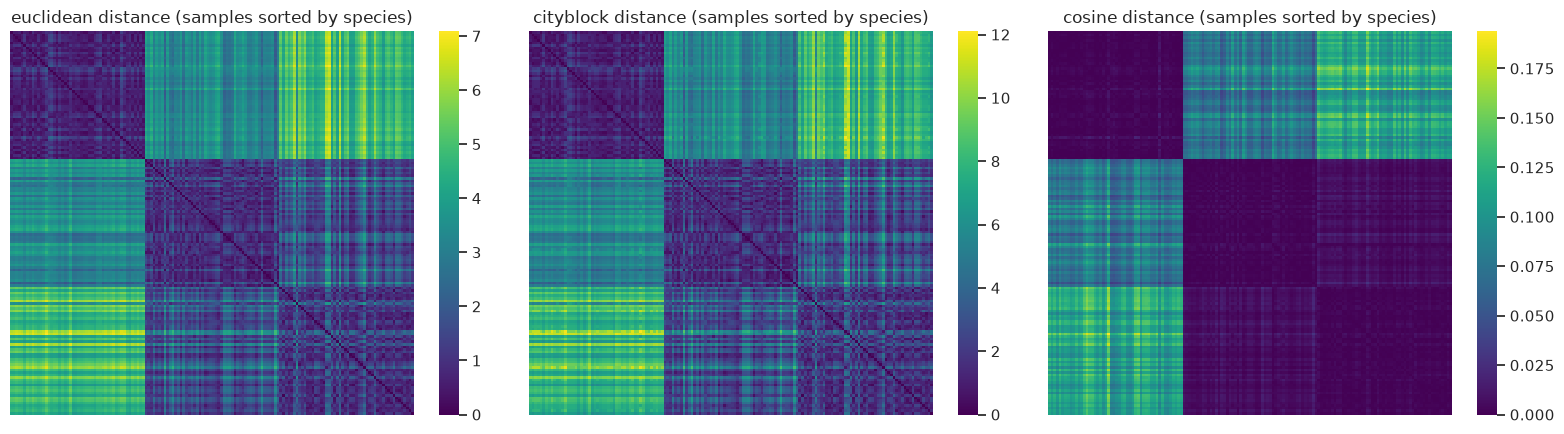

In [2]:
from scipy.spatial.distance import euclidean, cityblock, cosine, mahalanobis
iris = load_iris(as_frame=True); Xi = iris.data; yi = iris.target
a, b = Xi.iloc[0].values, Xi.iloc[60].values
VI = np.linalg.inv(np.cov(Xi.T))
print(pd.Series({"euclidean": euclidean(a, b), "manhattan": cityblock(a, b), "cosine": cosine(a, b), "mahalanobis": mahalanobis(a, b, VI)}).round(4).to_string())

# distance matrices (sorted by class) reveal cluster structure
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a_, m in zip(ax, ["euclidean", "cityblock", "cosine"]):
    from scipy.spatial.distance import squareform
    sns.heatmap(squareform(pdist(Xi.values, m)), ax=a_, cmap="viridis", xticklabels=False, yticklabels=False); a_.set_title(f"{m} distance (samples sorted by species)")
plt.tight_layout(); plt.show()

### A2. K-means (from scratch)
Minimise the distortion $J=\sum_n\sum_k r_{nk}\lVert\mathbf x_n-\boldsymbol\mu_k\rVert^2$ by alternating
(**E**) assign each point to its nearest centre, (**M**) set each centre to the mean of its points. $J$ never increases, so the algorithm converges to a *local* minimum
→ use several restarts and **k-means++** seeding.

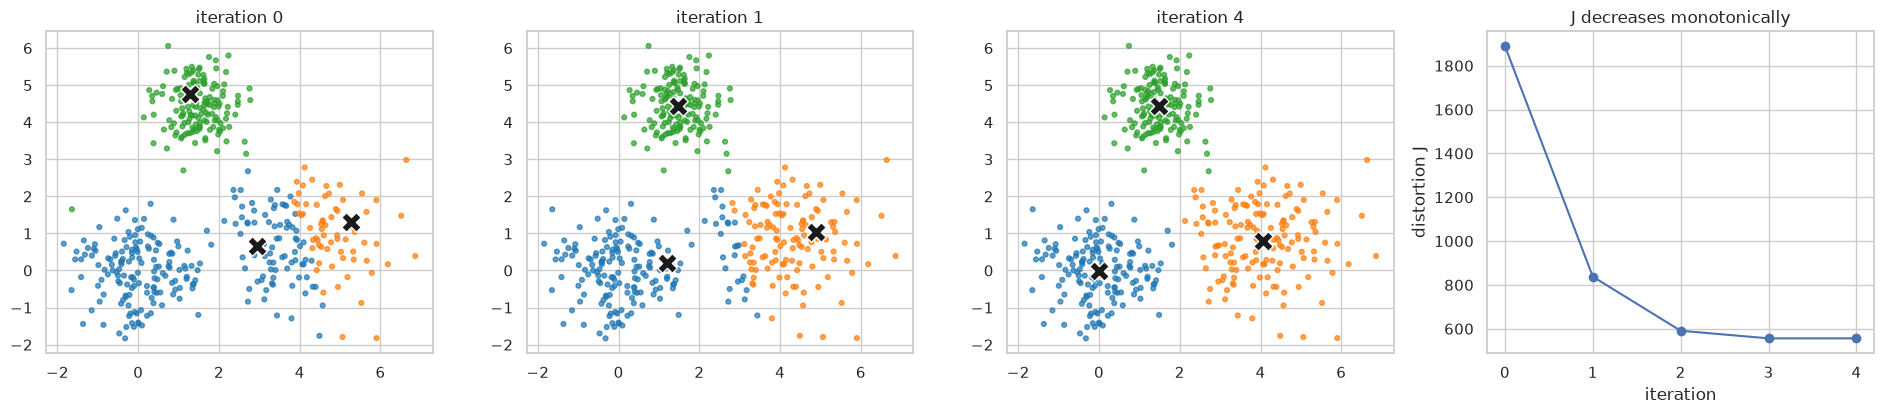

J (ours) = 556.14    J (sklearn inertia) = 556.14    ARI between the two partitions = 1.000


In [3]:
def kmeans(X, k, n_init=10, max_iter=100, seed=0, init="kmeans++", record=False):
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        # initialisation
        if init == "kmeans++":
            C = [X[rng.integers(len(X))]]
            for _ in range(k - 1):
                d2 = np.min(((X[:, None] - np.array(C)[None]) ** 2).sum(-1), axis=1)
                C.append(X[rng.choice(len(X), p=d2 / d2.sum())])
            C = np.array(C)
        else:
            C = X[rng.choice(len(X), k, replace=False)]
        hist, Cs = [], [C.copy()]
        for _ in range(max_iter):
            d = ((X[:, None] - C[None]) ** 2).sum(-1)               # E-step: distances to centres
            z = d.argmin(1)
            hist.append(d[np.arange(len(X)), z].sum())               # distortion J
            Cn = np.array([X[z == j].mean(0) if np.any(z == j) else C[j] for j in range(k)])   # M-step
            Cs.append(Cn.copy())
            if np.allclose(Cn, C): break
            C = Cn
        if best is None or hist[-1] < best["J"]:
            best = dict(centers=C, labels=z, J=hist[-1], history=hist, trace=Cs)
    return best

Xb, yb = make_blobs(450, centers=[[0, 0], [4, 1], [1.5, 4.5]], cluster_std=[0.8, 1.0, 0.6], random_state=7)
res = kmeans(Xb, 3, n_init=1, init="random", seed=3)
fig, ax = plt.subplots(1, 4, figsize=(19, 4.3))
for a_, it in zip(ax[:3], [0, 1, len(res["trace"]) - 2]):
    C = res["trace"][it]; z = ((Xb[:, None] - C[None]) ** 2).sum(-1).argmin(1)
    a_.scatter(*Xb.T, c=[PAL[i] for i in z], s=12, alpha=.7); a_.scatter(*C.T, c="k", marker="X", s=200, edgecolor="w"); a_.set_title(f"iteration {it}")
ax[3].plot(res["history"], "o-"); ax[3].set(xlabel="iteration", ylabel="distortion J", title="J decreases monotonically")
plt.tight_layout(); plt.show()

ours = kmeans(Xb, 3, n_init=10); sk = KMeans(3, n_init=10, random_state=0).fit(Xb)
print(f"J (ours) = {ours['J']:.2f}    J (sklearn inertia) = {sk.inertia_:.2f}    ARI between the two partitions = {adjusted_rand_score(ours['labels'], sk.labels_):.3f}")

### A3. Mixtures of Gaussians and EM (from scratch)
$p(\mathbf x)=\sum_k\pi_k\mathcal N(\mathbf x|\boldsymbol\mu_k,\Sigma_k)$ with latent assignment $z$. EM maximises the likelihood by alternating

* **E-step** – responsibilities $\gamma_{nk}=\dfrac{\pi_k\mathcal N(\mathbf x_n|\mu_k,\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_n|\mu_j,\Sigma_j)}$
* **M-step** – $N_k=\sum_n\gamma_{nk}$, $\mu_k=\frac1{N_k}\sum\gamma_{nk}\mathbf x_n$, $\Sigma_k=\frac1{N_k}\sum\gamma_{nk}(\mathbf x_n-\mu_k)(\mathbf x_n-\mu_k)^\top$, $\pi_k=N_k/N$.

*Alternative view of EM:* each iteration maximises a lower bound on $\ln p(X|\theta)$ so the log-likelihood never decreases.
K-means is the limiting case of EM for spherical Gaussians with $\Sigma_k=\epsilon I$, $\epsilon\to0$ (hard assignments).

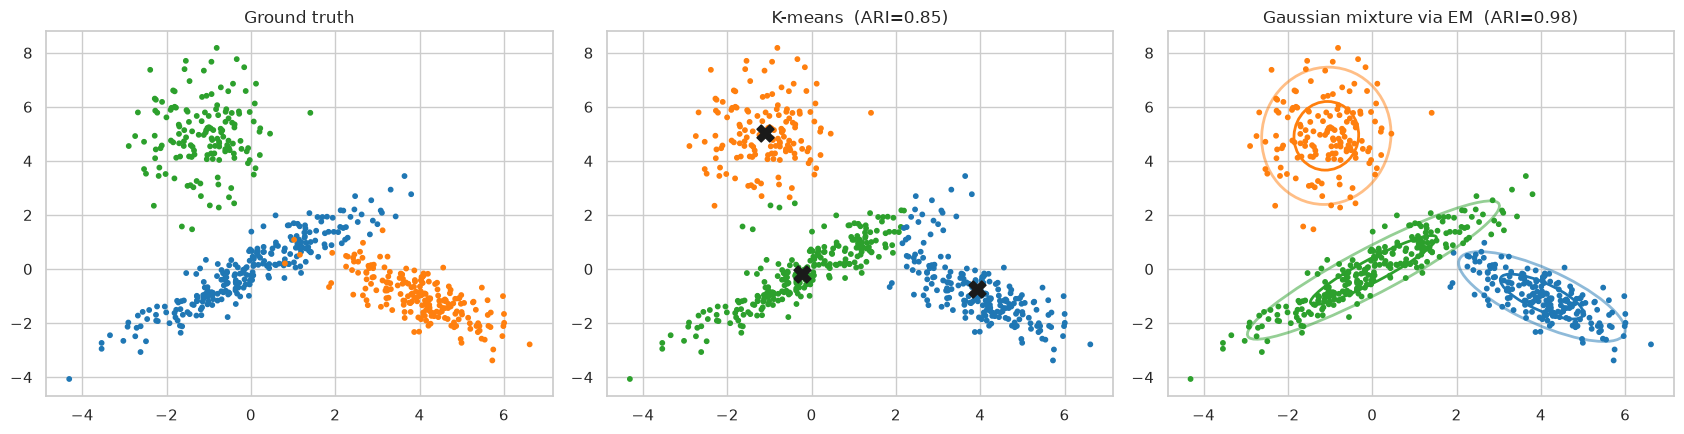

EM converged in 16 iterations; log-likelihood non-decreasing: True
final log-lik  ours=-2126.01   sklearn=-2126.04


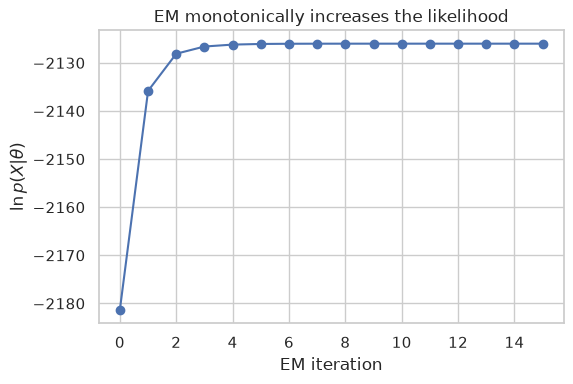

In [4]:
class MyGMM:
    def __init__(self, k, max_iter=200, tol=1e-6, reg=1e-6, seed=0): self.k, self.max_iter, self.tol, self.reg, self.seed = k, max_iter, tol, reg, seed

    def _estep(self, X):
        logp = np.stack([np.log(self.pi_[j]) + multivariate_normal.logpdf(X, self.mu_[j], self.S_[j]) for j in range(self.k)], 1)
        ll = np.logaddexp.reduce(logp, axis=1)                      # log p(x_n)
        return np.exp(logp - ll[:, None]), ll.sum()

    def fit(self, X):
        N, D = X.shape
        km = KMeans(self.k, n_init=5, random_state=self.seed).fit(X)              # initialise from K-means
        self.mu_ = km.cluster_centers_.copy()
        self.S_ = np.array([np.cov(X[km.labels_ == j].T) + self.reg * np.eye(D) for j in range(self.k)])
        self.pi_ = np.bincount(km.labels_, minlength=self.k) / N
        self.ll_hist_ = []
        for _ in range(self.max_iter):
            R, ll = self._estep(X); self.ll_hist_.append(ll)
            Nk = R.sum(0)
            self.mu_ = (R.T @ X) / Nk[:, None]
            self.S_ = np.array([((R[:, j, None] * (X - self.mu_[j])).T @ (X - self.mu_[j])) / Nk[j] + self.reg * np.eye(D) for j in range(self.k)])
            self.pi_ = Nk / N
            if len(self.ll_hist_) > 1 and abs(self.ll_hist_[-1] - self.ll_hist_[-2]) < self.tol: break
        self.resp_ = self._estep(X)[0]; self.n_params_ = self.k * (D + D * (D + 1) / 2) + self.k - 1; self.N_ = N
        return self

    def predict(self, X): return self._estep(X)[0].argmax(1)
    def bic(self): return -2 * self.ll_hist_[-1] + self.n_params_ * np.log(self.N_)

def draw_ellipse(ax, mu, S, color, ks=(1, 2)):
    v, V = np.linalg.eigh(S); ang = np.degrees(np.arctan2(V[1, 1], V[0, 1]))
    for k in ks: ax.add_patch(Ellipse(mu, 2 * k * np.sqrt(v[1]), 2 * k * np.sqrt(v[0]), angle=ang, fill=False, ec=color, lw=2, alpha=1 if k == 1 else .5))

# data with elongated, correlated clusters — K-means' spherical assumption struggles here
rng = np.random.default_rng(2)
Xg = np.r_[rng.multivariate_normal([0, 0], [[2.2, 1.8], [1.8, 1.7]], 250), rng.multivariate_normal([4, -1], [[1.0, -.6], [-.6, .7]], 200), rng.multivariate_normal([-1, 5], [[.6, 0], [0, 1.4]], 150)]
yg = np.r_[np.zeros(250), np.ones(200), np.full(150, 2)]

gmm = MyGMM(3).fit(Xg); km = KMeans(3, n_init=10, random_state=0).fit(Xg)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(*Xg.T, c=[PAL[int(i)] for i in yg], s=10); ax[0].set_title("Ground truth")
ax[1].scatter(*Xg.T, c=[PAL[i] for i in km.labels_], s=10); ax[1].scatter(*km.cluster_centers_.T, c="k", marker="X", s=150); ax[1].set_title(f"K-means  (ARI={adjusted_rand_score(yg, km.labels_):.2f})")
ax[2].scatter(*Xg.T, c=[PAL[i] for i in gmm.predict(Xg)], s=10)
for j in range(3): draw_ellipse(ax[2], gmm.mu_[j], gmm.S_[j], PAL[j])
ax[2].set_title(f"Gaussian mixture via EM  (ARI={adjusted_rand_score(yg, gmm.predict(Xg)):.2f})")
plt.tight_layout(); plt.show()

d = np.diff(gmm.ll_hist_)
print(f"EM converged in {len(gmm.ll_hist_)} iterations; log-likelihood non-decreasing: {np.all(d > -1e-8)}")
sk = GaussianMixture(3, covariance_type="full", random_state=0, n_init=5).fit(Xg)
print(f"final log-lik  ours={gmm.ll_hist_[-1]:.2f}   sklearn={sk.score(Xg) * len(Xg):.2f}")
plt.figure(figsize=(6, 3.8)); plt.plot(gmm.ll_hist_, "o-"); plt.xlabel("EM iteration"); plt.ylabel(r"$\ln p(X|\theta)$"); plt.title("EM monotonically increases the likelihood"); plt.show()

### A4. Hierarchical (agglomerative) clustering
Start with each point as its own cluster and repeatedly merge the two closest clusters. The **linkage** defines cluster distance:
*single* (min), *complete* (max), *average*, *Ward* (minimum increase in within-cluster variance). The result is a **dendrogram**; cutting at a height gives a flat clustering.

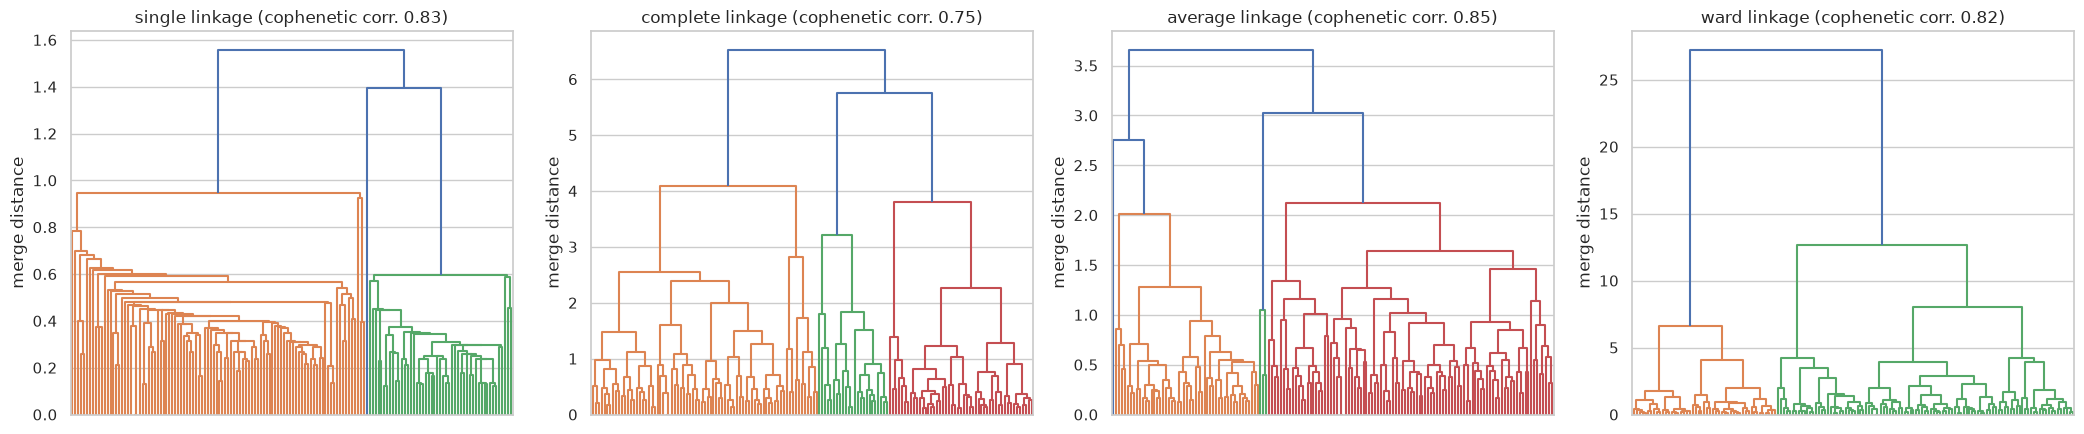

In [5]:
Xs = StandardScaler().fit_transform(Xi)
fig, ax = plt.subplots(1, 4, figsize=(21, 4.5))
for a_, method in zip(ax, ["single", "complete", "average", "ward"]):
    Z = linkage(Xs, method); c, _ = cophenet(Z, pdist(Xs))
    dendrogram(Z, no_labels=True, ax=a_, color_threshold=0.7 * Z[-1, 2]); a_.set_title(f"{method} linkage (cophenetic corr. {c:.2f})"); a_.set_ylabel("merge distance")
plt.tight_layout(); plt.show()

### A5. Evaluating clustering output
* **Internal** (no labels): *silhouette* $s=\frac{b-a}{\max(a,b)}\in[-1,1]$ (a = mean intra-cluster distance, b = mean distance to nearest other cluster), distortion/inertia, BIC for mixtures.
* **External** (labels available): *Adjusted Rand Index*, *normalised mutual information*, homogeneity & completeness. They are permutation-invariant — cluster IDs need not match class IDs.

---
## Part B — Practice

## Practice 1 — K-means, Gaussian mixtures and hierarchical clustering to categorise data
We categorise the **Iris** flowers (4 measurements) *without* using the species labels, then use the labels only to **evaluate**.
All features are standardised; a PCA projection to 2-D is used purely for visualisation.

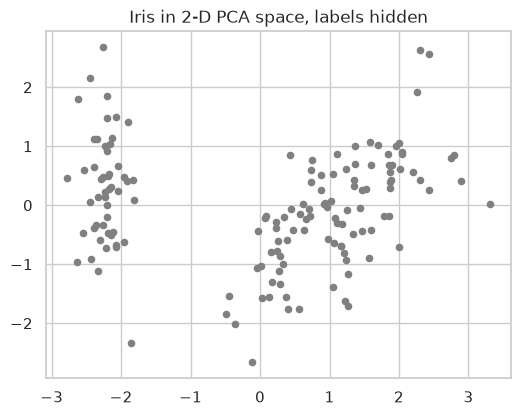

In [6]:
X = StandardScaler().fit_transform(Xi.values); y = yi.values
proj = PCA(2).fit_transform(X)
plt.figure(figsize=(6, 4.5)); plt.scatter(*proj.T, c="gray", s=20); plt.title("Iris in 2-D PCA space, labels hidden"); plt.show()

### K-means: choosing k with the elbow and silhouette methods

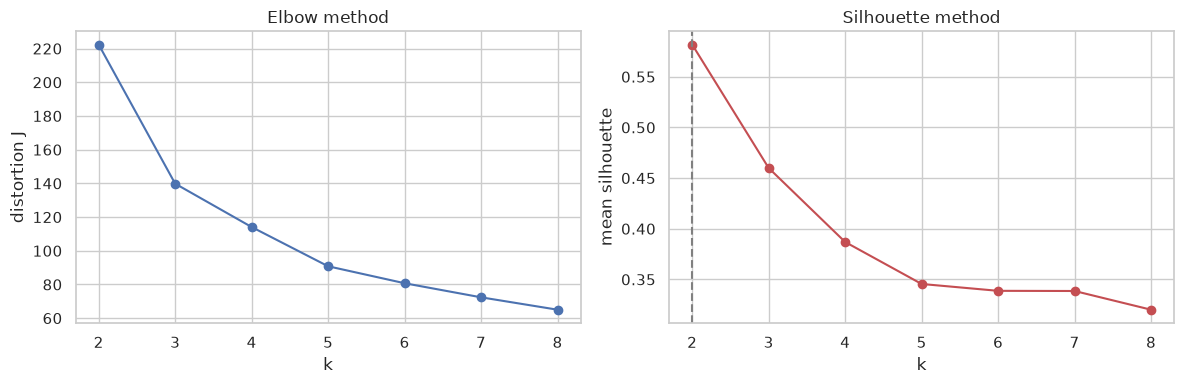

best k by silhouette: 2 (true number of species = 3; silhouette favours the well-separated setosa vs. rest)


In [7]:
ks = range(2, 9); inertia, sil = [], []
for k in ks:
    m = kmeans(X, k, n_init=10, seed=0); inertia.append(m["J"]); sil.append(silhouette_score(X, m["labels"]))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set(xlabel="k", ylabel="distortion J", title="Elbow method")
ax[1].plot(ks, sil, "o-r"); ax[1].set(xlabel="k", ylabel="mean silhouette", title="Silhouette method"); ax[1].axvline(list(ks)[int(np.argmax(sil))], ls="--", c="gray")
plt.tight_layout(); plt.show()
print("best k by silhouette:", list(ks)[int(np.argmax(sil))], "(true number of species = 3; silhouette favours the well-separated setosa vs. rest)")

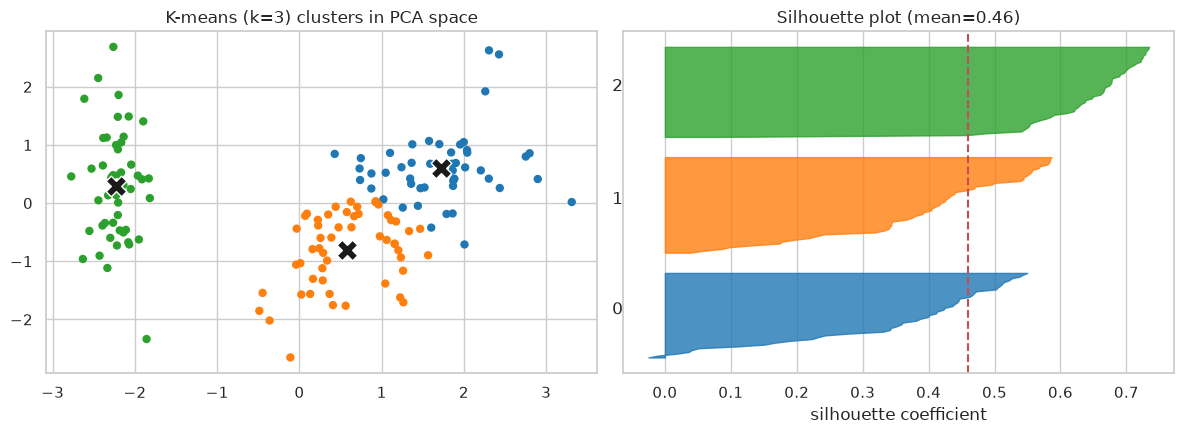

In [8]:
km = kmeans(X, 3, n_init=20, seed=1); lab_km = km["labels"]
sv = silhouette_samples(X, lab_km)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(*proj.T, c=[PAL[i] for i in lab_km], s=25)
cp = PCA(2).fit(X).transform(km["centers"]); ax[0].scatter(*cp.T, c="k", marker="X", s=220, edgecolor="w"); ax[0].set_title("K-means (k=3) clusters in PCA space")
yl = 10
for j in range(3):
    s = np.sort(sv[lab_km == j]); ax[1].fill_betweenx(np.arange(yl, yl + len(s)), 0, s, color=PAL[j], alpha=.8); ax[1].text(-0.08, yl + len(s) / 2, str(j)); yl += len(s) + 10
ax[1].axvline(sv.mean(), c="r", ls="--"); ax[1].set(xlabel="silhouette coefficient", title=f"Silhouette plot (mean={sv.mean():.2f})", yticks=[])
plt.tight_layout(); plt.show()

### Gaussian mixture model: choosing the number of components with BIC

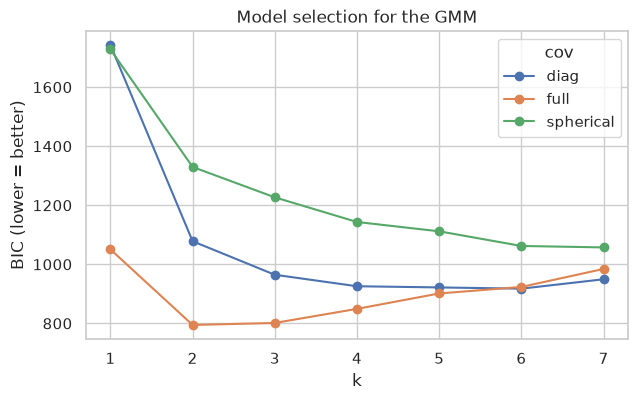

k               1       2       3       4       5       6       7
cov                                                              
diag       1742.8  1078.2   964.7   925.8   921.8   917.7   949.4
full       1050.7   794.7   801.5   849.2   901.4   923.5   984.4
spherical  1727.8  1329.7  1226.9  1143.4  1111.8  1062.3  1057.3

BIC prefers k=2 for Iris (versicolor and virginica overlap heavily); we still use k=3 below because we know there are three species.


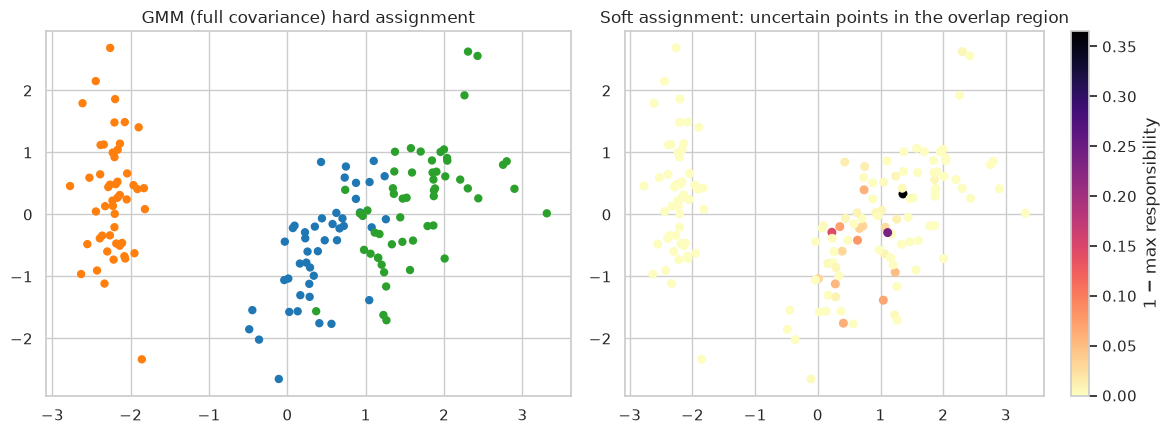

In [9]:
rows = []
for k in range(1, 8):
    for cov in ["spherical", "diag", "full"]:
        g = GaussianMixture(k, covariance_type=cov, n_init=3, random_state=0).fit(X); rows.append((k, cov, g.bic(X)))
bic = pd.DataFrame(rows, columns=["k", "cov", "BIC"]).pivot(index="k", columns="cov", values="BIC")
plt.figure(figsize=(7, 4)); bic.plot(marker="o", ax=plt.gca()); plt.ylabel("BIC (lower = better)"); plt.title("Model selection for the GMM"); plt.show()
print(bic.round(1).T.to_string())
print("\nBIC prefers k=2 for Iris (versicolor and virginica overlap heavily); we still use k=3 below because we know there are three species.")

gm = GaussianMixture(3, covariance_type="full", n_init=10, random_state=0).fit(X); lab_gm = gm.predict(X); post = gm.predict_proba(X)
unc = 1 - post.max(1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(*proj.T, c=[PAL[i] for i in lab_gm], s=25); ax[0].set_title("GMM (full covariance) hard assignment")
sc = ax[1].scatter(*proj.T, c=unc, cmap="magma_r", s=30); plt.colorbar(sc, ax=ax[1], label="1 − max responsibility"); ax[1].set_title("Soft assignment: uncertain points in the overlap region")
plt.tight_layout(); plt.show()

### Hierarchical clustering

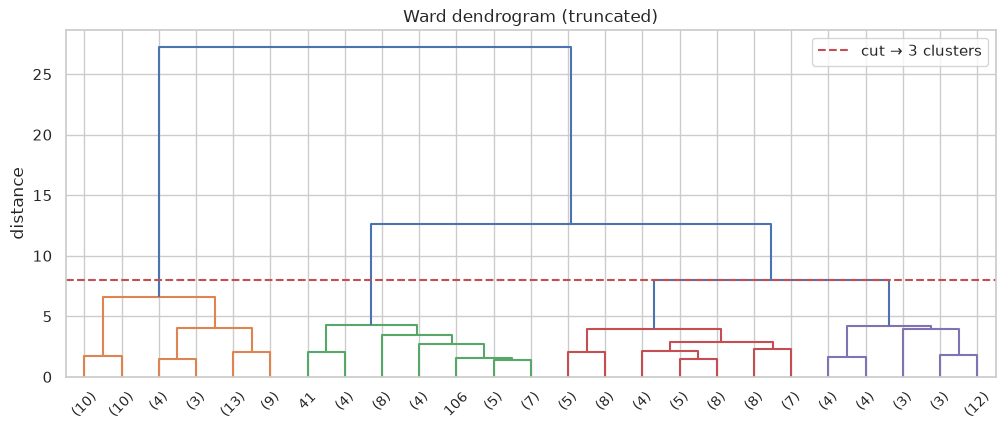

In [10]:
Zw = linkage(X, "ward")
plt.figure(figsize=(12, 4.5)); dendrogram(Zw, truncate_mode="lastp", p=25, show_leaf_counts=True, color_threshold=Zw[-3, 2])
plt.axhline(Zw[-3, 2] - 1e-6, c="r", ls="--", label="cut → 3 clusters"); plt.legend(); plt.title("Ward dendrogram (truncated)"); plt.ylabel("distance"); plt.show()
lab_h = fcluster(Zw, 3, "maxclust") - 1

### Comparison of all three methods

,silhouette,ARI,NMI,homogeneity,completeness
method,,,,,
K-means,0.460,0.620,0.659,0.659,0.660
Gaussian mixture,0.374,0.904,0.900,0.898,0.901
Hierarchical (Ward),0.447,0.615,0.675,0.658,0.694
Hierarchical (single),0.505,0.558,0.720,0.579,0.951


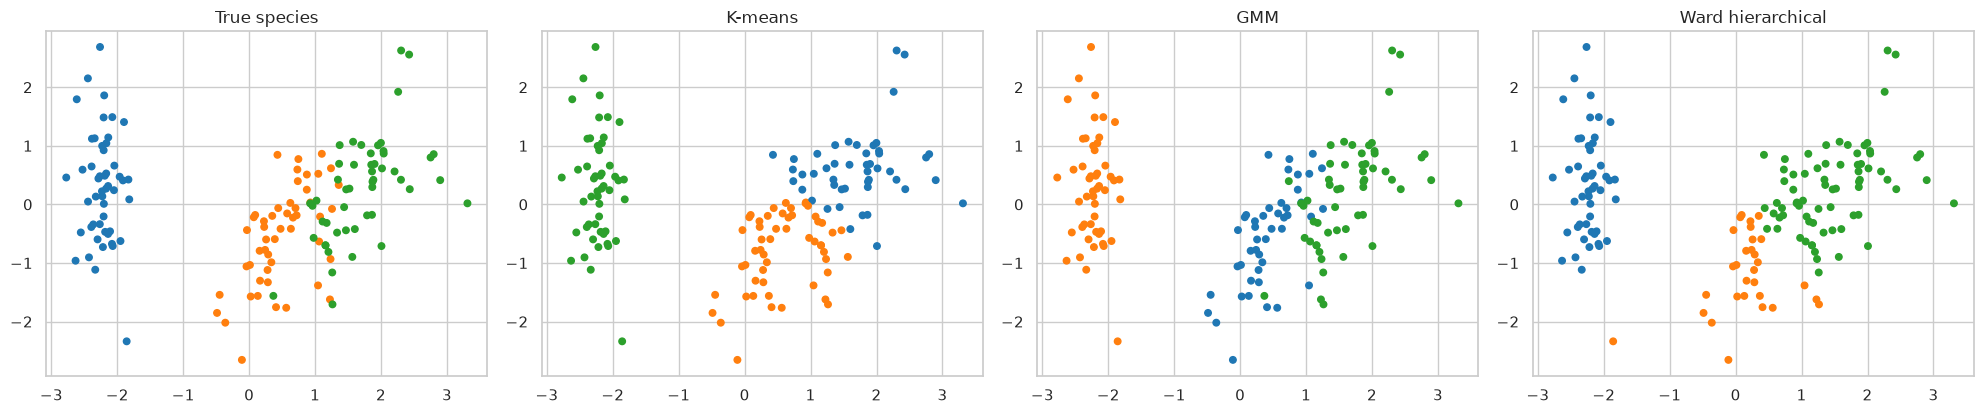

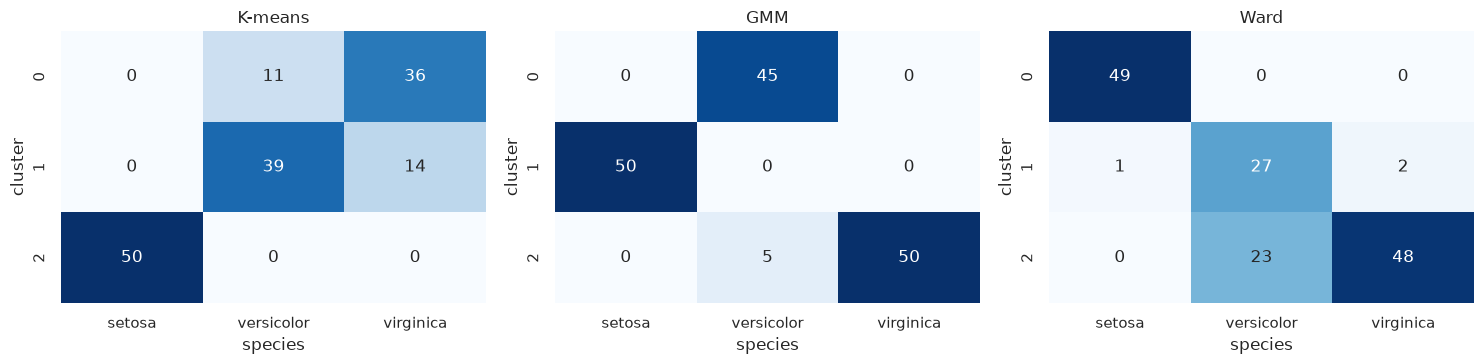

In [11]:
def scores(name, labels):
    return dict(method=name, silhouette=silhouette_score(X, labels), ARI=adjusted_rand_score(y, labels), NMI=normalized_mutual_info_score(y, labels),
                homogeneity=homogeneity_score(y, labels), completeness=completeness_score(y, labels))
table = pd.DataFrame([scores("K-means", lab_km), scores("Gaussian mixture", lab_gm), scores("Hierarchical (Ward)", lab_h),
                      scores("Hierarchical (single)", fcluster(linkage(X, "single"), 3, "maxclust") - 1)]).set_index("method").round(3)
display(table)

fig, ax = plt.subplots(1, 4, figsize=(20, 4.3))
for a_, (name, lab) in zip(ax, [("True species", y), ("K-means", lab_km), ("GMM", lab_gm), ("Ward hierarchical", lab_h)]):
    a_.scatter(*proj.T, c=[PAL[int(i)] for i in lab], s=22); a_.set_title(name)
plt.tight_layout(); plt.show()

# cluster ↔ class contingency tables
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a_, (name, lab) in zip(ax, [("K-means", lab_km), ("GMM", lab_gm), ("Ward", lab_h)]):
    sns.heatmap(pd.crosstab(pd.Series(lab, name="cluster"), pd.Series(iris.target_names[y], name="species")), annot=True, fmt="d", cmap="Blues", cbar=False, ax=a_); a_.set_title(name)
plt.tight_layout(); plt.show()

### When do the algorithms differ? Non-convex data (two moons)
K-means and a GMM assume compact, roughly elliptical clusters; **single-linkage** hierarchical clustering follows chains of neighbouring points.

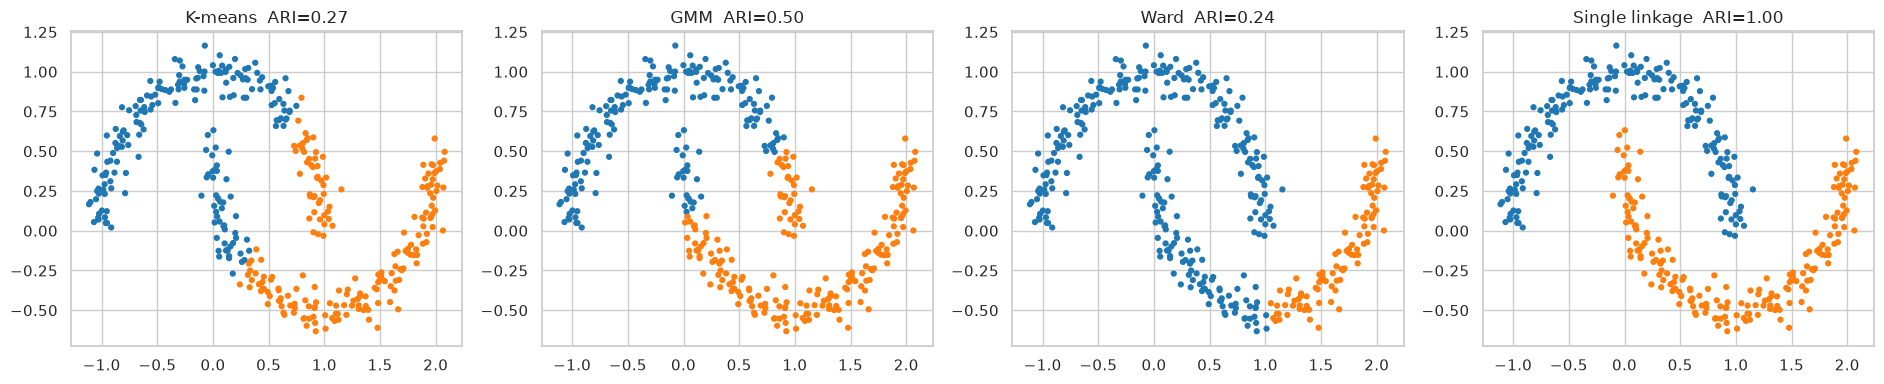

In [12]:
Xm, ym = make_moons(400, noise=0.07, random_state=0)
algos = {"K-means": KMeans(2, n_init=10, random_state=0).fit_predict(Xm),
         "GMM": GaussianMixture(2, n_init=5, random_state=0).fit(Xm).predict(Xm),
         "Ward": AgglomerativeClustering(2, linkage="ward").fit_predict(Xm),
         "Single linkage": AgglomerativeClustering(2, linkage="single").fit_predict(Xm)}
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for a_, (nme, l) in zip(ax, algos.items()):
    a_.scatter(*Xm.T, c=[PAL[i] for i in l], s=12); a_.set_title(f"{nme}  ARI={adjusted_rand_score(ym, l):.2f}")
plt.tight_layout(); plt.show()

## Practice 2 — Principal Component Analysis (PCA)
PCA finds orthogonal directions of maximal variance: the eigenvectors of the covariance matrix $\Sigma$ (equivalently the right singular vectors of the centred data matrix),
with eigenvalues $\lambda_k$ = variance captured. Projection to $M$ dims: $\mathbf z=U_M^\top(\mathbf x-\bar{\mathbf x})$; reconstruction: $\hat{\mathbf x}=\bar{\mathbf x}+U_M\mathbf z$.

### Step 1 – PCA from scratch (eigen-decomposition) and check against scikit-learn

In [13]:
class MyPCA:
    def __init__(self, n_components=None): self.n_components = n_components
    def fit(self, X):
        X = np.asarray(X, float); self.mean_ = X.mean(0); Xc = X - self.mean_
        C = Xc.T @ Xc / (len(X) - 1)                              # sample covariance
        vals, vecs = np.linalg.eigh(C); order = np.argsort(vals)[::-1]
        self.eigvals_, V = vals[order], vecs[:, order]
        for j in range(V.shape[1]):                               # deterministic sign convention
            if V[np.argmax(np.abs(V[:, j])), j] < 0: V[:, j] *= -1
        k = self.n_components or X.shape[1]
        self.components_ = V[:, :k].T; self.explained_variance_ = self.eigvals_[:k]
        self.explained_variance_ratio_ = self.eigvals_[:k] / self.eigvals_.sum()
        return self
    def transform(self, X): return (np.asarray(X, float) - self.mean_) @ self.components_.T
    def inverse_transform(self, Z): return Z @ self.components_ + self.mean_
    def fit_transform(self, X): return self.fit(X).transform(X)

mine = MyPCA().fit(X); ref = PCA().fit(X)
print("explained variance ratio  ours   :", mine.explained_variance_ratio_.round(4))
print("explained variance ratio  sklearn:", ref.explained_variance_ratio_.round(4))
print("components match up to sign:", np.allclose(np.abs(mine.components_), np.abs(ref.components_), atol=1e-6))
# same answer through the SVD route
U, s, Vt = np.linalg.svd(X - X.mean(0), full_matrices=False); print("SVD eigenvalues match:", np.allclose(s ** 2 / (len(X) - 1), mine.eigvals_))

explained variance ratio  ours   : [0.7296 0.2285 0.0367 0.0052]
explained variance ratio  sklearn: [0.7296 0.2285 0.0367 0.0052]
components match up to sign: True
SVD eigenvalues match: True


### Step 2 – Visualise: explained variance, projection, loadings

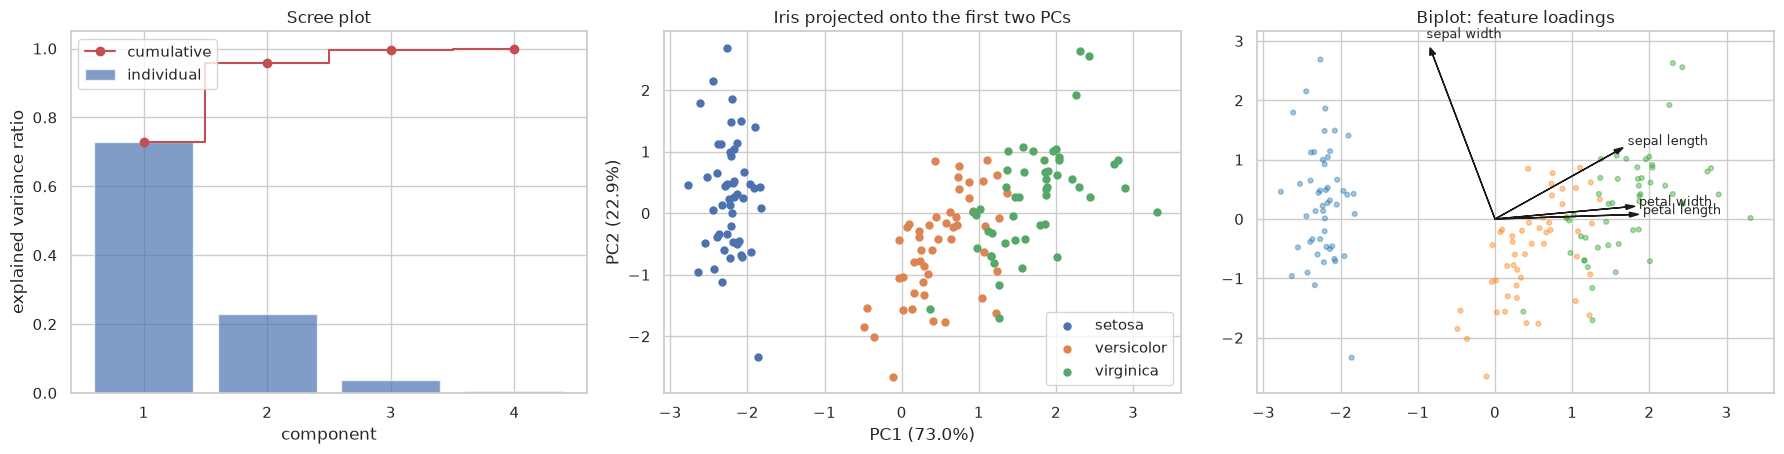

,PC1,PC2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


In [14]:
pca = MyPCA(2).fit(X); Z = pca.transform(X)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.7))
ev = mine.explained_variance_ratio_; ax[0].bar(range(1, 5), ev, alpha=.7, label="individual"); ax[0].step(range(1, 5), np.cumsum(ev), "r-o", where="mid", label="cumulative")
ax[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree plot", xticks=range(1, 5)); ax[0].legend()
for k, name in enumerate(iris.target_names): ax[1].scatter(*Z[y == k].T, label=name, s=25)
ax[1].set(xlabel=f"PC1 ({ev[0]:.1%})", ylabel=f"PC2 ({ev[1]:.1%})", title="Iris projected onto the first two PCs"); ax[1].legend()
# biplot
ax[2].scatter(*Z.T, c=[PAL[i] for i in y], s=12, alpha=.4)
for j, f in enumerate(Xi.columns):
    ax[2].arrow(0, 0, *pca.components_[:, j] * 3, color="k", head_width=.08); ax[2].text(*pca.components_[:, j] * 3.3, f.replace(" (cm)", ""), fontsize=9)
ax[2].set_title("Biplot: feature loadings"); plt.tight_layout(); plt.show()
display(pd.DataFrame(mine.components_[:2].T, index=Xi.columns, columns=["PC1", "PC2"]).round(3))

### Step 3 – Choosing the number of latent dimensions
Three common criteria: (a) cumulative explained variance ≥ 95 %, (b) Kaiser rule (eigenvalue > 1 on standardised data), (c) the **probabilistic PCA** held-out log-likelihood (Bishop §12.2) – pick the dimension that maximises cross-validated likelihood.
(a) and (b) are shown on the 64-dimensional **digits** data; (c) is demonstrated on synthetic data whose true latent dimension (5) is known, so we can check the answer.

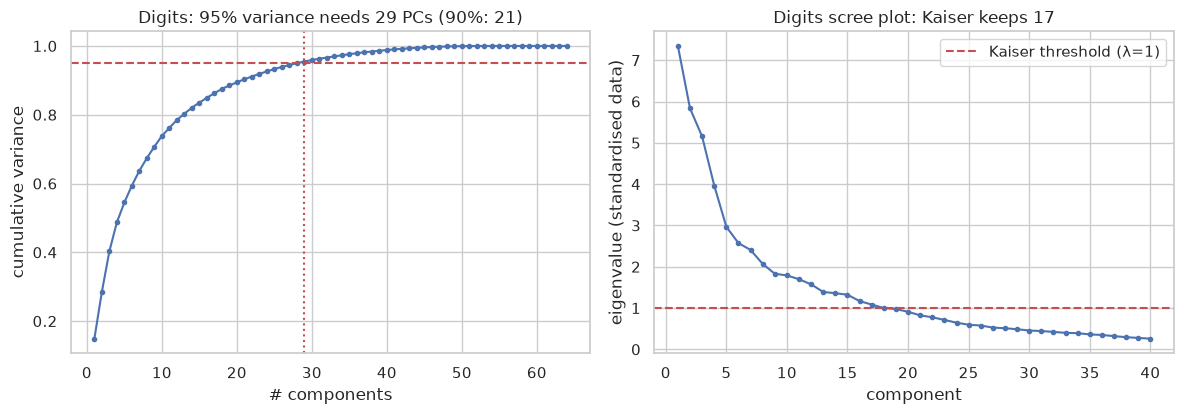

digits → 95%-variance rule: 29 PCs    Kaiser rule: 17 PCs


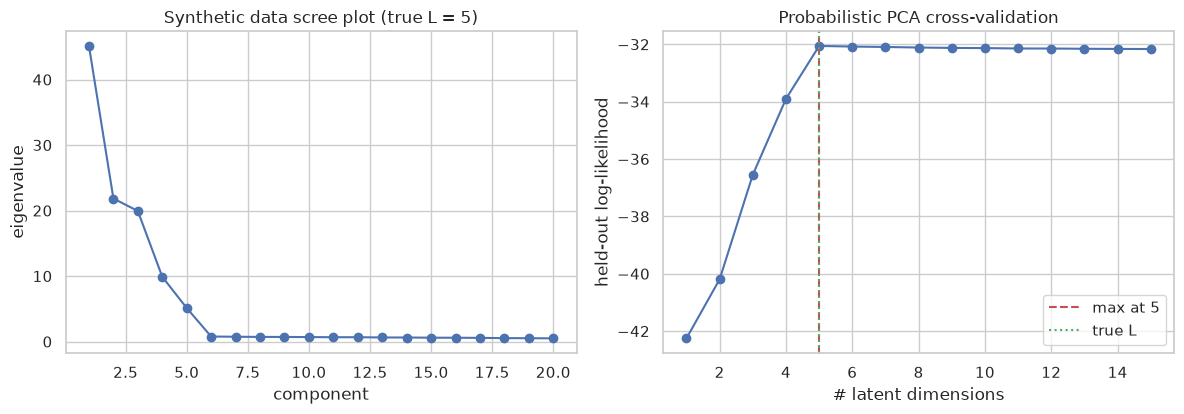

PPCA cross-validation selects 5 dimensions (truth: 5)


In [15]:
digits = load_digits(); Xd = digits.data; yd = digits.target
pd_ = PCA().fit(Xd); cum = np.cumsum(pd_.explained_variance_ratio_)
k95 = int(np.searchsorted(cum, 0.95) + 1); k90 = int(np.searchsorted(cum, 0.90) + 1)
Xds = StandardScaler().fit_transform(Xd[:, Xd.std(0) > 0]); kaiser = int((PCA().fit(Xds).explained_variance_ > 1).sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(range(1, 65), cum, "-o", ms=3); ax[0].axhline(.95, c="r", ls="--"); ax[0].axvline(k95, c="r", ls=":"); ax[0].set(xlabel="# components", ylabel="cumulative variance", title=f"Digits: 95% variance needs {k95} PCs (90%: {k90})")
ax[1].plot(range(1, 41), PCA().fit(Xds).explained_variance_[:40], "-o", ms=3); ax[1].axhline(1, c="r", ls="--", label="Kaiser threshold (λ=1)")
ax[1].set(xlabel="component", ylabel="eigenvalue (standardised data)", title=f"Digits scree plot: Kaiser keeps {kaiser}"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"digits → 95%-variance rule: {k95} PCs    Kaiser rule: {kaiser} PCs")

# (c) probabilistic PCA with a known truth: 20-D data generated from 5 latent factors + isotropic noise
rng = np.random.default_rng(0); L_true = 5
Xp = rng.normal(size=(800, L_true)) @ rng.normal(size=(L_true, 20)) + 0.8 * rng.normal(size=(800, 20))
dims = list(range(1, 16)); cv_ll = [cross_val_score(PCA(d), Xp, cv=5).mean() for d in dims]     # PCA.score = held-out PPCA log-likelihood
k_ppca = dims[int(np.argmax(cv_ll))]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ev = PCA().fit(Xp).explained_variance_; ax[0].plot(range(1, 21), ev, "o-"); ax[0].set(xlabel="component", ylabel="eigenvalue", title="Synthetic data scree plot (true L = 5)")
ax[1].plot(dims, cv_ll, "-o"); ax[1].axvline(k_ppca, c="r", ls="--", label=f"max at {k_ppca}"); ax[1].axvline(L_true, c="g", ls=":", label="true L"); ax[1].legend()
ax[1].set(xlabel="# latent dimensions", ylabel="held-out log-likelihood", title="Probabilistic PCA cross-validation")
plt.tight_layout(); plt.show()
print(f"PPCA cross-validation selects {k_ppca} dimensions (truth: {L_true})")

### Step 4 – Compression and reconstruction (digits)

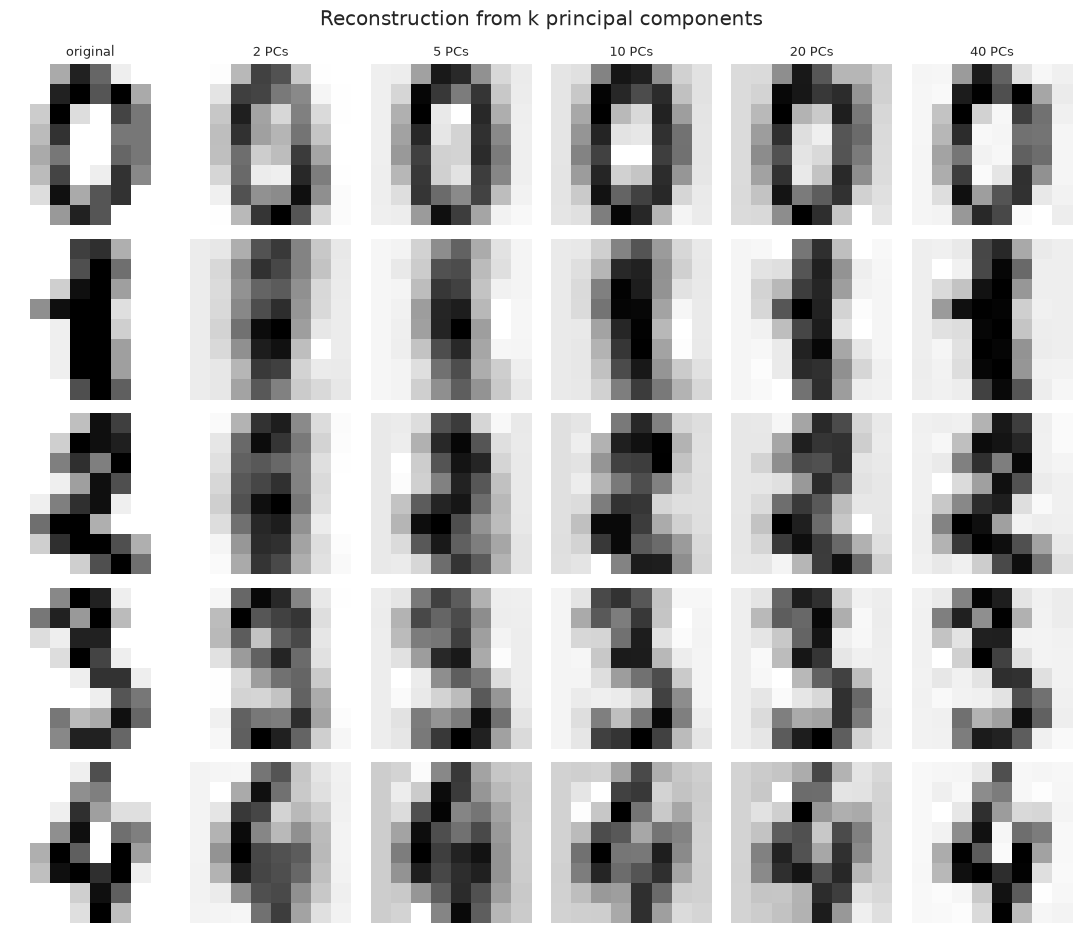

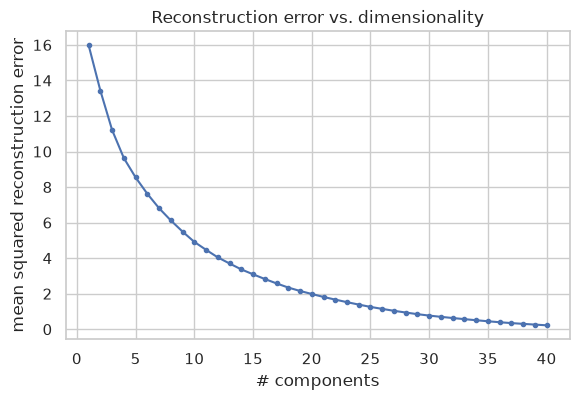

In [16]:
fig, ax = plt.subplots(5, 6, figsize=(11, 9.5))
ks = [2, 5, 10, 20, 40]
for r, i in enumerate([0, 1, 2, 3, 4]):
    ax[r, 0].imshow(digits.images[i], cmap="gray_r"); ax[r, 0].set_title("original" if r == 0 else "", fontsize=9)
    for c, k in enumerate(ks):
        p = PCA(k).fit(Xd); ax[r, c + 1].imshow(p.inverse_transform(p.transform(Xd[i:i + 1])).reshape(8, 8), cmap="gray_r")
        if r == 0: ax[r, c + 1].set_title(f"{k} PCs", fontsize=9)
for a_ in ax.ravel(): a_.axis("off")
plt.suptitle("Reconstruction from k principal components"); plt.tight_layout(); plt.show()

errs = [np.mean((Xd - PCA(k).fit(Xd).inverse_transform(PCA(k).fit(Xd).transform(Xd))) ** 2) for k in range(1, 41)]
plt.figure(figsize=(6.5, 4)); plt.plot(range(1, 41), errs, "o-", ms=3); plt.xlabel("# components"); plt.ylabel("mean squared reconstruction error"); plt.title("Reconstruction error vs. dimensionality"); plt.show()

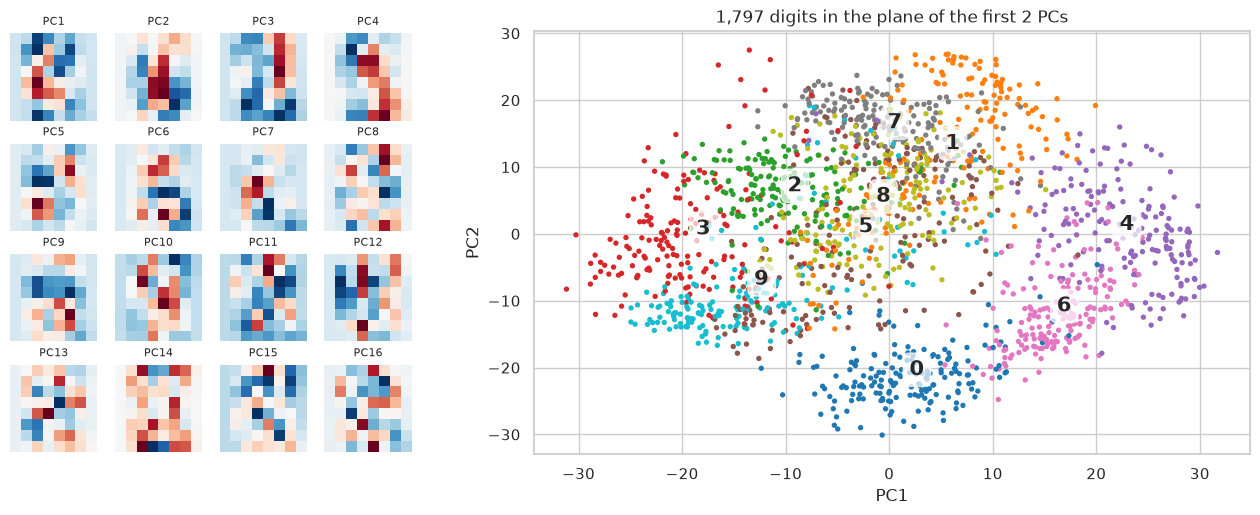

 2 PCs → 5-NN accuracy 0.595   |   K-means(10) ARI 0.393
 5 PCs → 5-NN accuracy 0.884   |   K-means(10) ARI 0.554


10 PCs → 5-NN accuracy 0.940   |   K-means(10) ARI 0.647


20 PCs → 5-NN accuracy 0.958   |   K-means(10) ARI 0.648
64 PCs → 5-NN accuracy 0.963   |   K-means(10) ARI 0.666


In [17]:
# the first principal axes as images ("eigen-digits") and a 2-D map of all digits
p = PCA(2).fit(Xd); Zd = p.transform(Xd)
pf = PCA(16).fit(Xd)
fig = plt.figure(figsize=(16, 5.5)); gs = fig.add_gridspec(4, 12)
for i in range(16): a_ = fig.add_subplot(gs[i // 4, i % 4]); a_.imshow(pf.components_[i].reshape(8, 8), cmap="RdBu_r"); a_.axis("off"); a_.set_title(f"PC{i+1}", fontsize=8)
a_ = fig.add_subplot(gs[:, 5:]); sc = a_.scatter(Zd[:, 0], Zd[:, 1], c=yd, cmap="tab10", s=8)
for d in range(10): a_.text(*Zd[yd == d].mean(0), str(d), fontsize=15, weight="bold", bbox=dict(boxstyle="round", fc="w", alpha=.7))
a_.set(xlabel="PC1", ylabel="PC2", title="1,797 digits in the plane of the first 2 PCs"); plt.show()

# does PCA help a downstream task + clustering?
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
for k in [2, 5, 10, 20, 64]:
    acc = cross_val_score(make_pipeline(PCA(k), KNeighborsClassifier(5)), Xd, yd, cv=5).mean()
    km_ = KMeans(10, n_init=5, random_state=0).fit(PCA(k).fit_transform(Xd)); print(f"{k:>2} PCs → 5-NN accuracy {acc:.3f}   |   K-means(10) ARI {adjusted_rand_score(yd, km_.labels_):.3f}")

### Step 5 – Factor analysis vs. PCA
Factor analysis (FA) models $\mathbf x=W\mathbf z+\boldsymbol\mu+\boldsymbol\epsilon$ with **per-feature noise variances** $\Psi$ (diagonal), while PPCA uses isotropic noise $\sigma^2I$ and PCA is the $\sigma^2\to0$ limit.
When features have different noise levels FA recovers the latent subspace better; PCA is drawn to high-variance noisy features.

subspace error vs. truth:  FA = 0.217   PCA = 1.293   (lower is better)


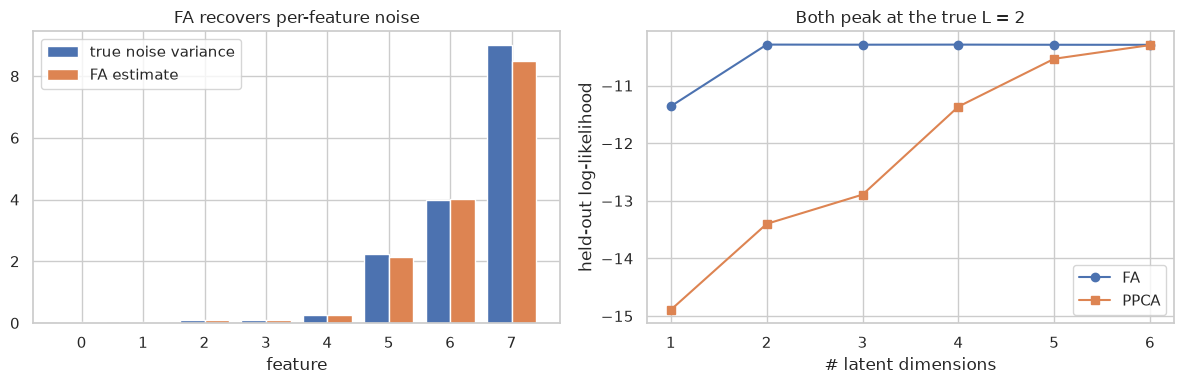

In [18]:
rng = np.random.default_rng(0); N, D, L = 1000, 8, 2
W = rng.normal(0, 1, (D, L)); noise_sd = np.array([0.2, 0.2, 0.3, 0.3, 0.5, 1.5, 2.0, 3.0])        # heteroscedastic noise
Zt = rng.normal(size=(N, L)); Xf = Zt @ W.T + rng.normal(size=(N, D)) * noise_sd

fa = FactorAnalysis(L, random_state=0).fit(Xf); pc = PCA(L).fit(Xf)
def subspace_err(A, B):                                   # distance between column spaces
    Qa, _ = np.linalg.qr(A); Qb, _ = np.linalg.qr(B); return np.linalg.norm(Qa @ Qa.T - Qb @ Qb.T)
print(f"subspace error vs. truth:  FA = {subspace_err(fa.components_.T, W):.3f}   PCA = {subspace_err(pc.components_.T, W):.3f}   (lower is better)")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(np.arange(D) - .2, noise_sd ** 2, .4, label="true noise variance"); ax[0].bar(np.arange(D) + .2, fa.noise_variance_, .4, label="FA estimate"); ax[0].set(xlabel="feature", title="FA recovers per-feature noise"); ax[0].legend()
ks = range(1, 7); ax[1].plot(ks, [cross_val_score(FactorAnalysis(k, random_state=0), Xf, cv=5).mean() for k in ks], "o-", label="FA"); ax[1].plot(ks, [cross_val_score(PCA(k), Xf, cv=5).mean() for k in ks], "s-", label="PPCA")
ax[1].set(xlabel="# latent dimensions", ylabel="held-out log-likelihood", title="Both peak at the true L = 2"); ax[1].legend(); plt.tight_layout(); plt.show()

## Summary
* Implemented **K-means** and **EM for Gaussian mixtures** from scratch, verified monotone convergence and agreement with scikit-learn; K-means is hard-assignment EM.
* Clustered Iris with K-means, GMM and hierarchical clustering; chose *k* via elbow/silhouette/BIC and evaluated with silhouette, ARI, NMI.
* Showed where each method fails (non-convex data) and how soft assignments expose uncertainty.
* Implemented **PCA** from scratch, validated against scikit-learn/SVD, used scree plots, cumulative variance, Kaiser and probabilistic-PCA CV to choose the dimension, performed compression/reconstruction and compared with factor analysis.